In [ ]:
import os
import gdown

file_id = '1b67VYi8SuLv8ru8oFNC9ZqZBLynZ4F3V'
zip_path = 'Dataset_Siap_Training.zip'

if not os.path.exists(zip_path):
    gdown.download(f'https://drive.google.com/uc?id=1b67VYi8SuLv8ru8oFNC9ZqZBLynZ4F3V', zip_path, quiet=False)
    print("Download selesai!")
else:
    print("File ZIP sudah ada di Colab.")

Downloading...
From: https://drive.google.com/uc?id=1b67VYi8SuLv8ru8oFNC9ZqZBLynZ4F3V
To: /content/Dataset_Siap_Training.zip
100%|██████████| 19.4M/19.4M [00:00<00:00, 175MB/s]

Download selesai!


In [ ]:
import zipfile
extract_path = 'Dataset_Terbagi_Final'

if not os.path.exists(extract_path):
    with zipfile.ZipFile('Dataset_Siap_Training.zip', 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Berhasil diekstrak ke folder '{extract_path}'.")
else:
    print(f"Folder '{extract_path}' sudah siap.")

print("Isi direktori:", os.listdir(extract_path))

Berhasil diekstrak ke folder 'Dataset_Terbagi_Final'.
Isi direktori: ['train', 'test', 'val']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_data_path = 'Dataset_Terbagi_Final/train'
val_data_path = 'Dataset_Terbagi_Final/val'
test_data_path = 'Dataset_Terbagi_Final/test'

img_height, img_width, batch_size = 224, 224, 32

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.2,
    height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
    horizontal_flip=True, fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("Memuat Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_data_path, target_size=(img_height, img_width),
    batch_size=batch_size, class_mode='binary', shuffle=True
)

print("Memuat Validation Data:")
val_generator = val_test_datagen.flow_from_directory(
    val_data_path, target_size=(img_height, img_width),
    batch_size=batch_size, class_mode='binary', shuffle=False
)

print("Memuat Testing Data:")
test_generator = val_test_datagen.flow_from_directory(
    test_data_path, target_size=(img_height, img_width),
    batch_size=batch_size, class_mode='binary', shuffle=False
)

Memuat Training Data:
Found 606 images belonging to 2 classes.
Memuat Validation Data:
Found 129 images belonging to 2 classes.
Memuat Testing Data:
Found 131 images belonging to 2 classes.


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D,
                                     Dropout, BatchNormalization)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import files

seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
print("Setup awal berhasil! Seed telah dikunci.")

Setup awal berhasil! Seed telah dikunci.


In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_data_path, target_size=(img_height, img_width),
    batch_size=batch_size, class_mode='binary',
    shuffle=True, seed=seed_value   # ← tambahkan ini
)

Found 606 images belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()
print(f"\nModel siap! Total params: {model.count_params():,}")
print(f"   Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"   Frozen params    : {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)


Model siap! Total params: 2,427,201
   Trainable params : 166,657
   Frozen params    : 2,260,544


In [ ]:
MODEL_PATH   = 'mobilenetv2_best_model.h5'
CSV_PATH     = 'mobilenetv2_training_history.csv'
EPOCHS       = 20

callbacks = [
    ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    CSVLogger(CSV_PATH, separator=',', append=False),
]

print("Memulai Training MobileNetV2 ...\n")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)
print("\nTraining selesai!")

Memulai Training MobileNetV2 ...

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5244 - loss: 0.9350 - precision: 0.5405 - recall: 0.6311
Epoch 1: val_accuracy improved from None to 0.59690, saving model to mobilenetv2_best_model.h5



Epoch 1: finished saving model to mobilenetv2_best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.5957 - loss: 0.8386 - precision: 0.5810 - recall: 0.6865 - val_accuracy: 0.5969 - val_loss: 0.7323 - val_precision: 0.7826 - val_recall: 0.2769
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.7643 - loss: 0.5392 - precision: 0.7702 - recall: 0.7488
Epoch 2: val_accuracy improved from 0.59690 to 0.65116, saving model to mobilenetv2_best_model.h5



Epoch 2: finished saving model to mobilenetv2_best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 400ms/step - accuracy: 0.7442 - loss: 0.5718 - precision: 0.7587 - recall: 0.7162 - val_accuracy: 0.6512 - val_loss: 0.7187 - val_precision: 0.8333 - val_recall: 0.3846
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.8222 - loss: 0.4075 - precision: 0.8135 - recall: 0.8279
Epoch 3: val_accuracy improved from 0.65116 to 0.74419, saving model to mobilenetv2_best_model.h5



Epoch 3: finished saving model to mobilenetv2_best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 423ms/step - accuracy: 0.8036 - loss: 0.4357 - precision: 0.8026 - recall: 0.8053 - val_accuracy: 0.7442 - val_loss: 0.5909 - val_precision: 0.8636 - val_recall: 0.5846
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.8164 - loss: 0.4101 - precision: 0.8076 - recall: 0.8400
Epoch 4: val_accuracy did not improve from 0.74419
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 431ms/step - accuracy: 0.8152 - loss: 0.4197 - precision: 0.8051 - recall: 0.8317 - val_accuracy: 0.7364 - val_loss: 0.6169 - val_precision: 0.8298 - val_recall: 0.6000
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.8439 - loss: 0.3673 - precision: 0.8455 - recall: 0.8509
Epoch 5: val_accuracy did not improve from 0.74419
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 371ms/step - accuracy: 0.8515 - loss: 0.3506 - precision: 0.8447 - recall: 0.8614 - val_accuracy: 0.7132 - val_loss: 0.6225 - val_precision: 0.7917 - val_recall: 0


Epoch 9: finished saving model to mobilenetv2_best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 518ms/step - accuracy: 0.8878 - loss: 0.2411 - precision: 0.8754 - recall: 0.9043 - val_accuracy: 0.7674 - val_loss: 0.5507 - val_precision: 0.7966 - val_recall: 0.7231
Epoch 10/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.8906 - loss: 0.2071 - precision: 0.8668 - recall: 0.9161
Epoch 10: val_accuracy did not improve from 0.76744
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 438ms/step - accuracy: 0.8960 - loss: 0.2174 - precision: 0.8846 - recall: 0.9109 - val_accuracy: 0.7674 - val_loss: 0.5779 - val_precision: 0.7869 - val_recall: 0.7385
Epoch 11/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.9055 - loss: 0.2375 - precision: 0.8974 - recall: 0.9153
Epoch 11: val_accuracy improved from 0.76744 to 0.78295, saving model to mobilenetv2_best_model.h5



Epoch 11: finished saving model to mobilenetv2_best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 394ms/step - accuracy: 0.9059 - loss: 0.2397 - precision: 0.9073 - recall: 0.9043 - val_accuracy: 0.7829 - val_loss: 0.5219 - val_precision: 0.8136 - val_recall: 0.7385
Epoch 12/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9163 - loss: 0.2184 - precision: 0.9217 - recall: 0.9218
Epoch 12: val_accuracy did not improve from 0.78295
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 434ms/step - accuracy: 0.9158 - loss: 0.2029 - precision: 0.9091 - recall: 0.9241 - val_accuracy: 0.7519 - val_loss: 0.5686 - val_precision: 0.7619 - val_recall: 0.7385
Epoch 13/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9105 - loss: 0.2314 - precision: 0.9083 - recall: 0.9166
Epoch 13: val_accuracy did not improve from 0.78295
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 437ms/step - accuracy: 0.9010 - loss: 0.2535 - precision: 0.8932 - recall: 0.9109 - val_accuracy: 0.7752 - val_loss: 0.5423 - val_precision: 0.8000 - val_reca


Epoch 18: finished saving model to mobilenetv2_best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 473ms/step - accuracy: 0.9439 - loss: 0.1579 - precision: 0.9353 - recall: 0.9538 - val_accuracy: 0.7984 - val_loss: 0.5875 - val_precision: 0.8095 - val_recall: 0.7846
Epoch 19/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9163 - loss: 0.1910 - precision: 0.9276 - recall: 0.9080
Epoch 19: val_accuracy improved from 0.79845 to 0.80620, saving model to mobilenetv2_best_model.h5



Epoch 19: finished saving model to mobilenetv2_best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 415ms/step - accuracy: 0.9274 - loss: 0.1784 - precision: 0.9331 - recall: 0.9208 - val_accuracy: 0.8062 - val_loss: 0.5893 - val_precision: 0.8030 - val_recall: 0.8154
Epoch 20/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9305 - loss: 0.1813 - precision: 0.9427 - recall: 0.9221
Epoch 20: val_accuracy improved from 0.80620 to 0.81395, saving model to mobilenetv2_best_model.h5



Epoch 20: finished saving model to mobilenetv2_best_model.h5
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 415ms/step - accuracy: 0.9422 - loss: 0.1576 - precision: 0.9408 - recall: 0.9439 - val_accuracy: 0.8140 - val_loss: 0.5820 - val_precision: 0.8154 - val_recall: 0.8154

Training selesai!


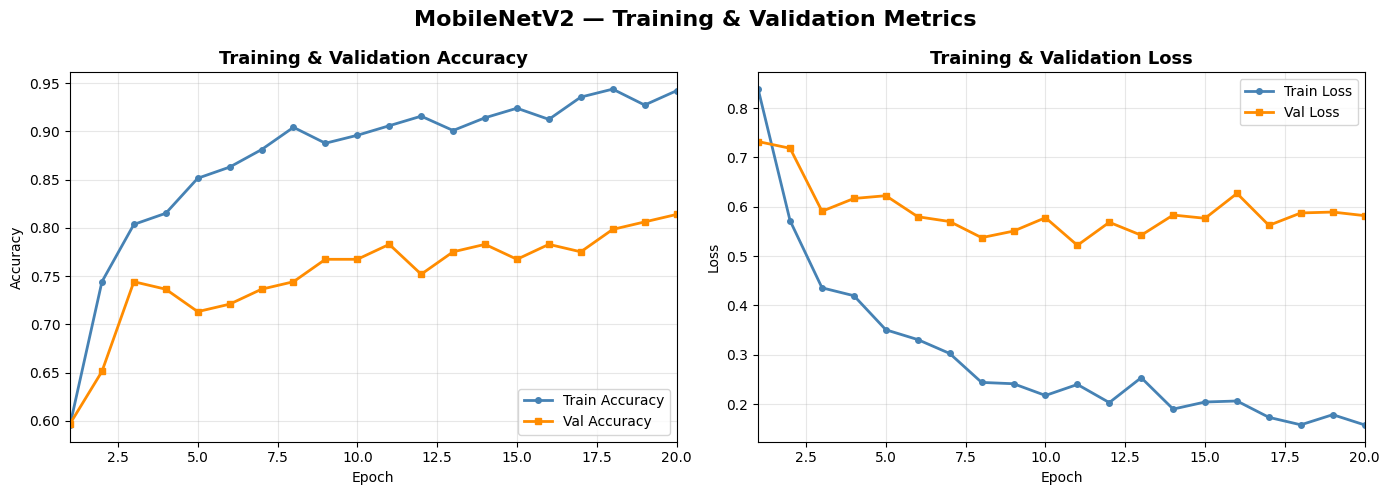

Plot berhasil ditampilkan di Colab!


In [ ]:
epochs_range = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV2 — Training & Validation Metrics',
             fontsize=16, fontweight='bold')
axes[0].plot(epochs_range, history.history['accuracy'],
             label='Train Accuracy', color='steelblue',
             linewidth=2, marker='o', markersize=4)
axes[0].plot(epochs_range, history.history['val_accuracy'],
             label='Val Accuracy', color='darkorange',
             linewidth=2, marker='s', markersize=4)
axes[0].set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([1, EPOCHS])

axes[1].plot(epochs_range, history.history['loss'],
             label='Train Loss', color='steelblue',
             linewidth=2, marker='o', markersize=4)
axes[1].plot(epochs_range, history.history['val_loss'],
             label='Val Loss', color='darkorange',
             linewidth=2, marker='s', markersize=4)
axes[1].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([1, EPOCHS])

plt.tight_layout()
plt.show()
print("Plot berhasil ditampilkan di Colab!")

Best model loaded dari 'mobilenetv2_best_model.h5'

5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.7710 - loss: 0.6058 - precision: 0.8000 - recall: 0.7273

  Test Accuracy  : 0.7710  (77.10%)
  Test Precision : 0.8000
  Test Recall    : 0.7273
  Test F1-Score  : 0.7619
  Test Loss      : 0.6058
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step


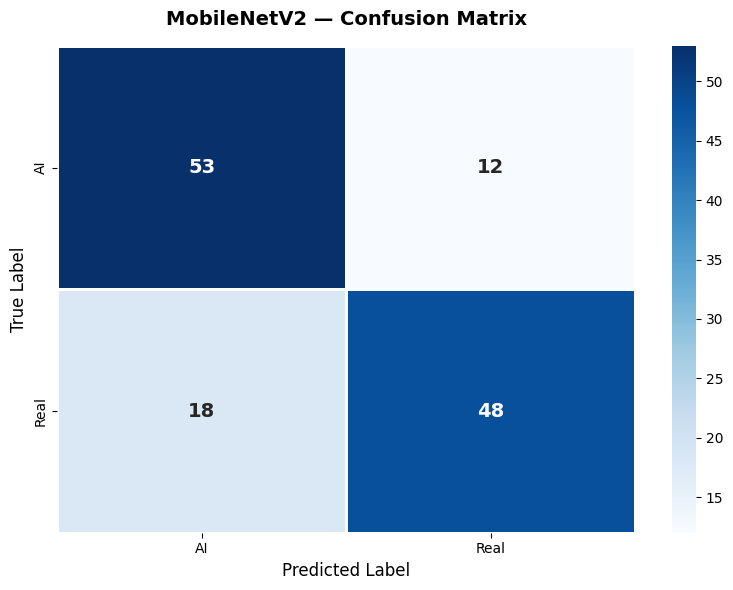

Confusion Matrix!

Classification Report:
              precision    recall  f1-score   support

          AI     0.7465    0.8154    0.7794        65
        Real     0.8000    0.7273    0.7619        66

    accuracy                         0.7710       131
   macro avg     0.7732    0.7713    0.7707       131
weighted avg     0.7734    0.7710    0.7706       131



In [ ]:
best_model = load_model(MODEL_PATH)
print(f"Best model loaded dari '{MODEL_PATH}'\n")

test_generator.reset()
results       = best_model.evaluate(test_generator, verbose=1)
test_loss      = results[0]
test_accuracy  = results[1]
test_precision = results[2]
test_recall    = results[3]
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-7)

print(f"\n{'='*50}")
print(f"  Test Accuracy  : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"  Test Precision : {test_precision:.4f}")
print(f"  Test Recall    : {test_recall:.4f}")
print(f"  Test F1-Score  : {test_f1:.4f}")
print(f"  Test Loss      : {test_loss:.4f}")
print(f"{'='*50}")

test_generator.reset()
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred       = (y_pred_probs > 0.5).astype(int).flatten()
y_true       = test_generator.classes
class_names  = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title('MobileNetV2 — Confusion Matrix',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()
print("Confusion Matrix!")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

In [ ]:
print("Mengunduh file ke komputer lokal...\n")

print("Downloading Model (.h5) ...")
files.download(MODEL_PATH)

print("Downloading Training History (.csv) ...")
files.download(CSV_PATH)

print(f"\nSelesai! Cek folder Downloads kamu.")
print(f"Model   : {MODEL_PATH}")
print(f"History : {CSV_PATH}")

Mengunduh file ke komputer lokal...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Selesai! Cek folder Downloads kamu.
Model   : mobilenetv2_best_model.h5
History : mobilenetv2_training_history.csv
